# IDS 705 — Predicting Recessions Using Global Macroeconomic Indicators
**Models:** Logistic Regression · Random Forest · XGBoost  
**Feature sets:** A (GDP only) · B (core macro) · C (all features)  
**Split:** Time-based — Train ≤2014 | Val 2015–2018 | Test 2019–2022

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    brier_score_loss,
    confusion_matrix,
    log_loss,
)

---
## 1. Load Data

In [2]:
world_bank = pd.read_parquet("../data/Merged/final_merged_panel.parquet")
print(world_bank.shape)
world_bank.head()

(12715, 33)


,country,year,wb_current_account_pct_gdp,wb_exports_pct_gdp,wb_gdp_growth,wb_gov_consumption_pct_gdp,wb_imports_pct_gdp,wb_inflation_cpi,imf_inflation_imf,non_null_feature_count,...,imf_inflation_imf_lag1,imf_inflation_imf_lag2,wb_current_account_pct_gdp_chg1,wb_exports_pct_gdp_chg1,wb_gdp_growth_chg1,wb_gov_consumption_pct_gdp_chg1,wb_imports_pct_gdp_chg1,wb_inflation_cpi_chg1,imf_inflation_imf_chg1,recession
0,Afghanistan,2002,-2.35799,10.420817,28.600001,22.109219,36.289077,12.686269,37.07650,2,...,37.07650,37.07650,0.0,0.0,-19.767723,0.0,0.0,0.000000,-4.50225,0
1,Afghanistan,2003,-2.35799,10.420817,8.832278,22.109219,36.289077,12.686269,32.57425,2,...,37.07650,37.07650,0.0,0.0,-19.767723,0.0,0.0,0.000000,-4.50225,0
2,Afghanistan,2004,-2.35799,10.420817,1.414118,22.109219,36.289077,12.686269,32.68175,2,...,32.57425,37.07650,0.0,0.0,-7.418160,0.0,0.0,0.000000,0.10750,0
3,Afghanistan,2005,-2.35799,10.420817,11.229715,22.109219,36.289077,12.686269,33.22900,3,...,32.68175,32.57425,0.0,0.0,9.815597,0.0,0.0,0.000000,0.54725,0
4,Afghanistan,2006,-2.35799,10.420817,5.357403,22.109219,36.289077,6.784597,32.25250,3,...,33.22900,32.68175,0.0,0.0,-5.872312,0.0,0.0,-5.901672,-0.97650,0


---
## 2. Target Construction

`recession_next_year = 1` if real GDP growth in **t+1** is negative for that country, 0 otherwise.  
This is a per-country definition — NOT the global 2008/2009/2020 label. Positive class rate ~15.3%.

In [ ]:
world_bank = world_bank.sort_values(["country", "year"]).reset_index(drop=True)

world_bank["recession_next_year"] = (
    world_bank.groupby("country")["wb_gdp_growth"].shift(-1).lt(0).astype(int)
)

world_bank = world_bank.dropna(subset=["recession_next_year"])
world_bank["recession_next_year"] = world_bank["recession_next_year"].astype(int)

print(f"Dataset: {world_bank.shape}")
print(f"Positive class rate: {world_bank['recession_next_year'].mean():.1%}")

Dataset: (12715, 34)
Positive class rate: 15.0%


---
## 3. Feature Sets A / B / C

In [ ]:
GDP_COLS = [
    c for c in world_bank.columns if "gdp_growth" in c and c != "recession_next_year"
]
CORE_COLS = GDP_COLS + [
    c
    for c in world_bank.columns
    if any(k in c for k in ["inflation", "gov_consumption"])
]
ALL_COLS = CORE_COLS + [
    c
    for c in world_bank.columns
    if any(k in c for k in ["trade", "imports", "exports", "current_account"])
]

# Deduplicate
CORE_COLS = list(dict.fromkeys(CORE_COLS))
ALL_COLS = list(dict.fromkeys(ALL_COLS))

print(f"A (GDP only):   {len(GDP_COLS)} features")
print(f"B (core macro): {len(CORE_COLS)} features")
print(f"C (all):        {len(ALL_COLS)} features")

A (GDP only):   4 features
B (core macro): 16 features
C (all):        28 features


---
## 4. Time-Based Split

Train ≤2014 · Val 2015–2018 · Test 2019–2022  
Test window includes COVID shock — val→test gap is regime shift, not overfitting.

In [ ]:
train_df = world_bank[world_bank["year"] <= 2014]
val_df = world_bank[(world_bank["year"] >= 2015) & (world_bank["year"] <= 2018)]
test_df = world_bank[world_bank["year"] >= 2019]

y_train = train_df["recession_next_year"]
y_val = val_df["recession_next_year"]
y_test = test_df["recession_next_year"]

print(f"Train: {len(train_df):,} obs | recession rate: {y_train.mean():.1%}")
print(f"Val:   {len(val_df):,} obs | recession rate: {y_val.mean():.1%}")
print(
    f"Test:  {len(test_df):,} obs | recession rate: {y_test.mean():.1%}  <- COVID window"
)

Train: 9,686 obs | recession rate: 15.5%
Val:   983 obs | recession rate: 11.2%
Test:  2,046 obs | recession rate: 14.6%  <- COVID window


---
## 5. Helper Functions

In [ ]:
def prepare_features(
    train_df, val_df, test_df, feature_cols, apply_pca=True, pca_variance=0.95
):
    """
    One-hot encode country, scale with StandardScaler, optionally apply PCA.
    All transforms fitted on train only to prevent leakage.
    """
    base_cols = [c for c in feature_cols if c in train_df.columns]

    def get_X(df):
        X = df[base_cols].copy().reset_index(drop=True)
        dummies = pd.get_dummies(
            df[["country"]], columns=["country"], drop_first=True
        ).reset_index(drop=True)
        return pd.concat([X, dummies], axis=1).fillna(0)

    X_tr = get_X(train_df)
    X_v = get_X(val_df).reindex(columns=X_tr.columns, fill_value=0)
    X_te = get_X(test_df).reindex(columns=X_tr.columns, fill_value=0)

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_v_s = scaler.transform(X_v)
    X_te_s = scaler.transform(X_te)

    if apply_pca:
        pca = PCA(n_components=pca_variance, random_state=42)
        X_tr_s = pca.fit_transform(X_tr_s)
        X_v_s = pca.transform(X_v_s)
        X_te_s = pca.transform(X_te_s)
        print(
            f"  PCA: {X_tr.shape[1]} -> {pca.n_components_} components "
            f"({pca.explained_variance_ratio_.sum():.1%} variance retained)"
        )

    return X_tr_s, X_v_s, X_te_s


def evaluate(model, X, y_true):
    """Primary metrics: probabilistic focus per report."""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)
    return {
        "AUC": round(roc_auc_score(y_true, y_prob), 3),
        "Brier": round(brier_score_loss(y_true, y_prob), 3),
        "AUPRC": round(average_precision_score(y_true, y_prob), 3),
        "LogLoss": round(log_loss(y_true, y_prob), 3),
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
    }


def plot_roc_pr(models_probs, y_true, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for label, y_prob in models_probs.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[0].plot(
            fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_true, y_prob):.3f})"
        )
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        axes[1].plot(
            rec,
            prec,
            label=f"{label} (AP={average_precision_score(y_true, y_prob):.3f})",
        )

    axes[0].plot([0, 1], [0, 1], "k--")
    axes[0].set(xlabel="FPR", ylabel="TPR", title=f"ROC — {title}")
    axes[0].legend(fontsize=8)

    axes[1].axhline(
        y_true.mean(), color="k", linestyle="--", label="Baseline (prevalence)"
    )
    axes[1].set(
        xlabel="Recall", ylabel="Precision", title=f"Precision-Recall — {title}"
    )
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# Store all results for Table B1
all_results = []
stored = {}  # store models + transformed X for later plotting
print("Helpers ready.")

Helpers ready.


---
## 7. Random Forest

Per report: 400 trees, max_depth=8, class_weight=balanced.  
RandomizedSearchCV tunes around these anchors.

In [10]:
rf_param_dist = {
    "n_estimators": [300, 400, 500],
    "max_depth": [6, 8, 10],
    "max_features": ["sqrt", 0.5, 0.7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

for feat_name, feat_cols in [("A", GDP_COLS), ("B", CORE_COLS), ("C", ALL_COLS)]:
    print(f"\n=== RandomForest | Feature Set {feat_name} ===")
    X_tr, X_v, X_te = prepare_features(train_df, val_df, test_df, feat_cols)

    search = RandomizedSearchCV(
        RandomForestClassifier(
            criterion="gini", class_weight="balanced", random_state=42, n_jobs=-1
        ),
        rf_param_dist,
        n_iter=10,
        cv=cv,
        scoring="roc_auc",
        n_jobs=1,
        random_state=42,
        verbose=2,
    )
    search.fit(X_tr, y_train)
    best = search.best_estimator_
    print(f"  Best: {search.best_params_} | CV AUC: {search.best_score_:.3f}")

    val_m = evaluate(best, X_v, y_val)
    test_m = evaluate(best, X_te, y_test)
    print(
        f"  Val  -> AUC: {val_m['AUC']} | Brier: {val_m['Brier']} | AUPRC: {val_m['AUPRC']}"
    )
    print(
        f"  Test -> AUC: {test_m['AUC']} | Brier: {test_m['Brier']} | AUPRC: {test_m['AUPRC']}"
    )

    key = f"RF_{feat_name}"
    stored[key] = {"model": best, "X_val": X_v, "X_test": X_te}
    all_results.append(
        {
            "Experiment": f"{feat_name}: {'GDP only' if feat_name=='A' else 'Core macro' if feat_name=='B' else 'All'}",
            "Model": "RandomForest",
            "Val AUC": val_m["AUC"],
            "Val Brier": val_m["Brier"],
            "Test AUC": test_m["AUC"],
            "Test Brier": test_m["Brier"],
            "Test AUPRC": test_m["AUPRC"],
        }
    )


=== RandomForest | Feature Set A ===
  PCA: 251 -> 236 components (95.1% variance retained)
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   0.9s
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   0.9s
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   0.9s
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   0.8s
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   0.9s
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.8s
[CV] END max_depth=6, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.9s
[CV] E

---
## 8. XGBoost

Per report: 400 trees, depth=4, learning_rate=0.05, scale_pos_weight=inverse class frequency.

In [11]:
neg, pos = np.bincount(y_train)
spw = neg / pos
print(f"scale_pos_weight: {spw:.2f} (neg/pos = {neg}/{pos})")

xgb_param_dist = {
    "n_estimators": [300, 400, 500],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [0.5, 1.0, 2.0],
}

for feat_name, feat_cols in [("A", GDP_COLS), ("B", CORE_COLS), ("C", ALL_COLS)]:
    print(f"\n=== XGBoost | Feature Set {feat_name} ===")
    X_tr, X_v, X_te = prepare_features(train_df, val_df, test_df, feat_cols)

    search = RandomizedSearchCV(
        XGBClassifier(
            eval_metric="logloss", scale_pos_weight=spw, random_state=42, n_jobs=-1
        ),
        xgb_param_dist,
        n_iter=10,
        cv=cv,
        scoring="roc_auc",
        n_jobs=1,
        random_state=42,
        verbose=2,
    )
    search.fit(X_tr, y_train)
    best = search.best_estimator_
    print(f"  Best: {search.best_params_} | CV AUC: {search.best_score_:.3f}")

    val_m = evaluate(best, X_v, y_val)
    test_m = evaluate(best, X_te, y_test)
    print(
        f"  Val  -> AUC: {val_m['AUC']} | Brier: {val_m['Brier']} | AUPRC: {val_m['AUPRC']}"
    )
    print(
        f"  Test -> AUC: {test_m['AUC']} | Brier: {test_m['Brier']} | AUPRC: {test_m['AUPRC']}"
    )

    key = f"XGB_{feat_name}"
    stored[key] = {"model": best, "X_val": X_v, "X_test": X_te}
    all_results.append(
        {
            "Experiment": f"{feat_name}: {'GDP only' if feat_name=='A' else 'Core macro' if feat_name=='B' else 'All'}",
            "Model": "XGBoost",
            "Val AUC": val_m["AUC"],
            "Val Brier": val_m["Brier"],
            "Test AUC": test_m["AUC"],
            "Test Brier": test_m["Brier"],
            "Test AUPRC": test_m["AUPRC"],
        }
    )

scale_pos_weight: 5.45 (neg/pos = 8184/1502)

=== XGBoost | Feature Set A ===
  PCA: 251 -> 236 components (95.1% variance retained)
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=400, reg_alpha=0.5, reg_lambda=1.0, subsample=0.9; total time=   1.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=400, reg_alpha=0.5, reg_lambda=1.0, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=400, reg_alpha=0.5, reg_lambda=1.0, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=400, reg_alpha=0.5, reg_lambda=1.0, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=400, reg_alpha=0.5, reg_lambda=1.0, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estima

---
## 9. Table B1 — All 9 Model × Feature Combinations

In [12]:
results_df = pd.DataFrame(all_results)
results_df = results_df.set_index(["Experiment", "Model"])
print("Table B1. Validation (2015-2018) and Test (2019-2022) metrics.")
print("Note: val->test AUC gap reflects COVID regime shift, not overfitting.\n")
results_df

Table B1. Validation (2015-2018) and Test (2019-2022) metrics.
Note: val->test AUC gap reflects COVID regime shift, not overfitting.



Val AUC  Val Brier  Test AUC  Test Brier  \
Experiment    Model                                                    
A: GDP only   RandomForest    0.819      0.140     0.688       0.174   
              RandomForest    0.819      0.140     0.688       0.174   
B: Core macro RandomForest    0.778      0.177     0.683       0.191   
C: All        RandomForest    0.787      0.145     0.695       0.163   
A: GDP only   XGBoost         0.814      0.177     0.690       0.206   
B: Core macro XGBoost         0.813      0.174     0.698       0.201   
C: All        XGBoost         0.809      0.177     0.695       0.195   

                            Test AUPRC  
Experiment    Model                     
A: GDP only   RandomForest       0.252  
              RandomForest       0.252  
B: Core macro RandomForest       0.239  
C: All        RandomForest       0.258  
A: GDP only   XGBoost            0.256  
B: Core macro XGBoost            0.270  
C: All        XGBoost            0.250

---
## 10. ROC & Precision-Recall Curves — Test Set, Feature Set C

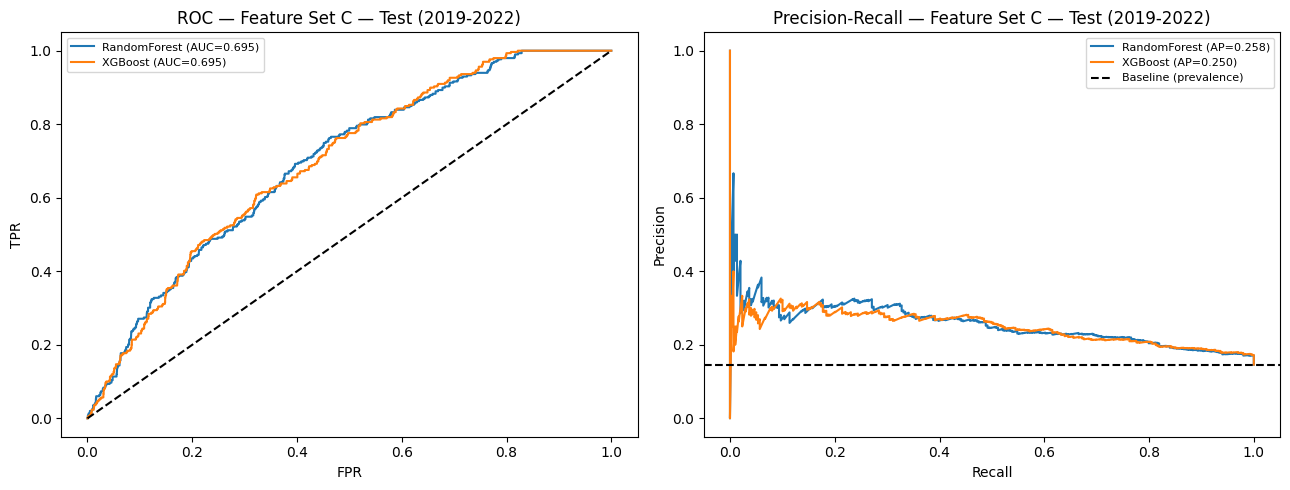

In [14]:
probs_C = {
    # "LogReg": stored["LogReg_C"]["model"].predict_proba(stored["LogReg_C"]["X_test"])[
    #     :, 1
    # ],
    "RandomForest": stored["RF_C"]["model"].predict_proba(stored["RF_C"]["X_test"])[
        :, 1
    ],
    "XGBoost": stored["XGB_C"]["model"].predict_proba(stored["XGB_C"]["X_test"])[:, 1],
}
plot_roc_pr(probs_C, y_test, title="Feature Set C — Test (2019-2022)")

---
## 11. Confusion Matrices at Threshold 0.5

**Sanity check only.** For policy use, threshold should be tuned to the cost of false negatives  
(missed recession = costly) vs false positives (false alarm = less costly but not free).

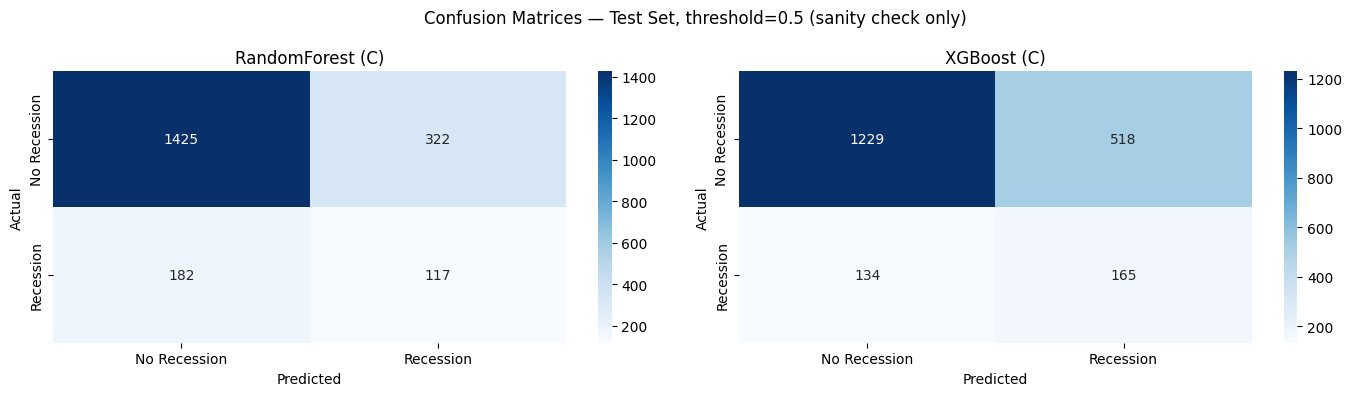

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label, key) in zip(
    axes,
    [
        # ("LogReg (C)", "LogReg_C"),
        ("RandomForest (C)", "RF_C"),
        ("XGBoost (C)", "XGB_C"),
    ],
):
    y_pred = stored[key]["model"].predict(stored[key]["X_test"])
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["No Recession", "Recession"],
        yticklabels=["No Recession", "Recession"],
    )
    ax.set_title(label)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle(
    "Confusion Matrices — Test Set, threshold=0.5 (sanity check only)", fontsize=12
)
plt.tight_layout()
plt.show()

---
## 12. Feature Importance — RF & XGBoost (Feature Set C)

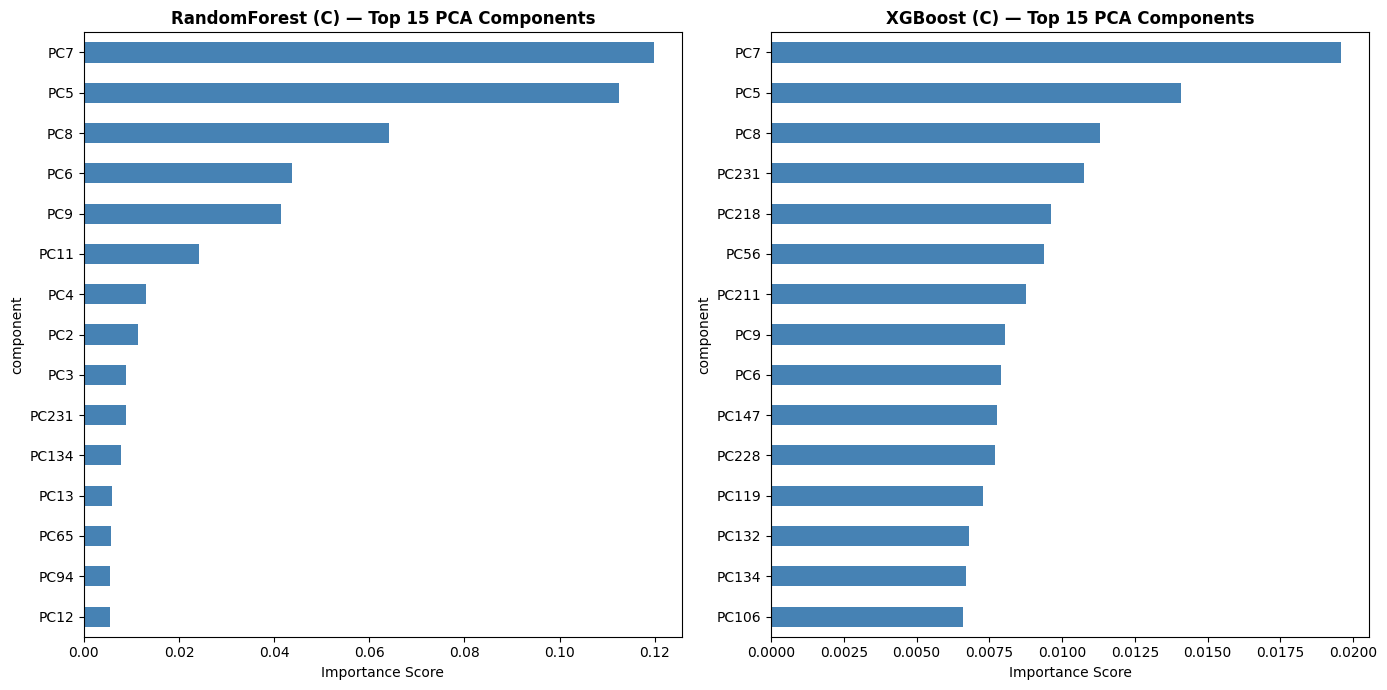

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (label, key) in zip(
    axes, [("RandomForest (C)", "RF_C"), ("XGBoost (C)", "XGB_C")]
):
    n = stored[key]["model"].n_features_in_
    imp_df = (
        pd.DataFrame(
            {
                "component": [f"PC{i+1}" for i in range(n)],
                "importance": stored[key]["model"].feature_importances_,
            }
        )
        .sort_values("importance", ascending=False)
        .head(15)
        .sort_values("importance")
    )
    imp_df.plot.barh(
        x="component", y="importance", ax=ax, color="steelblue", legend=False
    )
    ax.set_title(f"{label} — Top 15 PCA Components", fontweight="bold")
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()